# 01 - Exploración de DroneRF

En este notebook miro qué archivos de DroneRF tengo y cargo dos ejemplos: uno de fondo y uno con actividad de dron. La idea es empezar tranqui: ver si los datos cargan bien, graficar algo en el tiempo y revisar cómo voy a separar las ventanas sin mezclar grupos.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from aps_drone_rf.config import (
    DATA_DIR,
    DRONERF_TIME_FS_HZ,
    FIGURES_DIR,
    INTERIM_DATA_DIR,
    ensure_project_dirs,
)
from aps_drone_rf.estilo import aplicar_estilo_matplotlib, color_clase, nombre_clase
from aps_drone_rf.io import discover_signal_manifest, load_record
from aps_drone_rf.plots import save_figure
from aps_drone_rf.preprocessing import normalize_signal, segment_signal
from aps_drone_rf.synthetic import add_awgn, pure_tone, white_noise

ensure_project_dirs()
aplicar_estilo_matplotlib()

SEED = 42
plt.rcParams["figure.figsize"] = (8, 3)
plt.rcParams["axes.grid"] = True


## Primero veo qué archivos hay

DroneRF es pesado, así que los datos no van a GitHub. Este notebook busca los archivos en `DATA_DIR`. Si no encuentra datos reales, igual puede seguir con señales sintéticas para que el flujo no se corte.


In [2]:
manifest = discover_signal_manifest(DATA_DIR)
manifest.to_csv(INTERIM_DATA_DIR / "signal_manifest.csv", index=False)

print(f"Archivos encontrados: {len(manifest)}")

if manifest.empty:
    print("No encontré DroneRF local. Cuando esté descargado, se vuelve a correr este notebook.")
else:
    tabla = manifest.copy()
    tabla["archivo"] = tabla["path"].map(lambda value: Path(value).name)

    columnas = [
        "archivo",
        "label",
        "group_id",
        "suffix",
        "dronerf_code",
        "dronerf_part",
        "dronerf_segment",
    ]
    columnas = [col for col in columnas if col in tabla.columns]

    display(tabla[columnas].head(10))
    display(manifest["label"].value_counts(dropna=False).rename("cantidad"))
    display(manifest.groupby("label")["group_id"].nunique().rename("grupos"))


Archivos encontrados: 158


,archivo,label,group_id,suffix,dronerf_code,dronerf_part,dronerf_segment
0,00000H_0.csv,fondo,dronerf_00000_0,.csv,00000,H,0
1,00000H_1.csv,fondo,dronerf_00000_1,.csv,00000,H,1
2,00000H_15.csv,fondo,dronerf_00000_15,.csv,00000,H,15
3,00000H_16.csv,fondo,dronerf_00000_16,.csv,00000,H,16
4,00000H_17.csv,fondo,dronerf_00000_17,.csv,00000,H,17
5,00000H_18.csv,fondo,dronerf_00000_18,.csv,00000,H,18
6,00000H_19.csv,fondo,dronerf_00000_19,.csv,00000,H,19
7,00000H_2.csv,fondo,dronerf_00000_2,.csv,00000,H,2
8,00000H_20.csv,fondo,dronerf_00000_20,.csv,00000,H,20
9,00000H_3.csv,fondo,dronerf_00000_3,.csv,00000,H,3


label
dron     126
fondo     32
Name: cantidad, dtype: int64

label
dron     63
fondo    16
Name: grupos, dtype: int64

## Ahora cargo dos señales de ejemplo

Tomo un ejemplo de fondo y otro con actividad de dron. Esto es solo una primera mirada para ver las señales en el tiempo.


Fuente usada: DroneRF local
fs = 40000000.0 Hz
grupo fondo = dronerf_00000_0
grupo dron = dronerf_10000_0


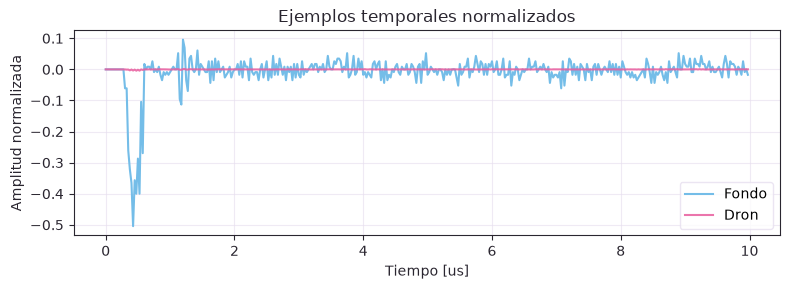

In [3]:
N = 2_000
fs = 2_000.0

if manifest.empty or not {"fondo", "dron"}.issubset(set(manifest["label"])):
    ruido_fondo = white_noise(N, sigma=0.5, seed=SEED)
    _, tono = pure_tone(180.0, fs, 1.0, amplitude=0.9)

    xx_fondo = normalize_signal(ruido_fondo)
    xx_dron = normalize_signal(add_awgn(tono, snr_db=8.0, seed=SEED + 1))
    grupo_fondo = "sintetico_fondo"
    grupo_dron = "sintetico_dron"
    fuente = "señales sintéticas"
else:
    fs = DRONERF_TIME_FS_HZ
    tabla = manifest[manifest["label"].isin(["fondo", "dron"])].copy()

    if "dronerf_part" in tabla.columns:
        parte_l = tabla[tabla["dronerf_part"].str.upper() == "L"]
        if not parte_l.empty:
            tabla = parte_l

    fila_fondo = tabla[tabla["label"] == "fondo"].iloc[0]
    fila_dron = tabla[tabla["label"] == "dron"].iloc[0]

    rec_fondo = load_record(fila_fondo, fs_hz=fs, normalize=True)
    rec_dron = load_record(fila_dron, fs_hz=fs, normalize=True)

    xx_fondo = np.real(rec_fondo.signal[:N])
    xx_dron = np.real(rec_dron.signal[:N])
    grupo_fondo = rec_fondo.group_id
    grupo_dron = rec_dron.group_id
    fuente = "DroneRF local"

ts = 1 / fs
tt = np.arange(N) * ts

if fuente == "DroneRF local":
    tt_grafico = tt * 1e6
    unidad_tiempo = "us"
else:
    tt_grafico = tt
    unidad_tiempo = "s"

print(f"Fuente usada: {fuente}")
print(f"fs = {fs:.1f} Hz")
print(f"grupo fondo = {grupo_fondo}")
print(f"grupo dron = {grupo_dron}")

fig, ax = plt.subplots()
ax.plot(tt_grafico[:400], xx_fondo[:400], label=nombre_clase("fondo"), color=color_clase("fondo"))
ax.plot(tt_grafico[:400], xx_dron[:400], label=nombre_clase("dron"), color=color_clase("dron"), alpha=0.85)
ax.set_title("Ejemplos temporales normalizados")
ax.set_xlabel(f"Tiempo [{unidad_tiempo}]")
ax.set_ylabel("Amplitud normalizada")
ax.legend()
save_figure(fig, FIGURES_DIR / "nb01_ejemplos_temporales.png")
plt.show()


## Después pruebo la segmentación

Como los archivos son largos, después los parto en ventanas más chicas. Lo importante es que todas las ventanas que salen del mismo archivo mantengan el mismo `group_id`.


In [4]:
window_size = 512
hop_size = 256

ventanas_fondo, meta_fondo = segment_signal(
    xx_fondo,
    window_size=window_size,
    hop_size=hop_size,
    group_id=grupo_fondo,
    label="fondo",
)

ventanas_dron, meta_dron = segment_signal(
    xx_dron,
    window_size=window_size,
    hop_size=hop_size,
    group_id=grupo_dron,
    label="dron",
)

metadata = pd.concat([meta_fondo, meta_dron], ignore_index=True)

print(f"Ventanas de fondo: {len(ventanas_fondo)}")
print(f"Ventanas con dron: {len(ventanas_dron)}")
display(metadata.head())
display(metadata.groupby("label")["group_id"].nunique().rename("grupos"))


Ventanas de fondo: 6
Ventanas con dron: 6


,window_id,group_id,label,start,stop
0,dronerf_00000_0:0,dronerf_00000_0,fondo,0,512
1,dronerf_00000_0:1,dronerf_00000_0,fondo,256,768
2,dronerf_00000_0:2,dronerf_00000_0,fondo,512,1024
3,dronerf_00000_0:3,dronerf_00000_0,fondo,768,1280
4,dronerf_00000_0:4,dronerf_00000_0,fondo,1024,1536


label
dron     1
fondo    1
Name: grupos, dtype: int64